In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [3]:
np.random.seed(42)
zones = ['Z1','Z2','Z3','Z4','Z5','Z6']
dates = pd.date_range('2025-01-01', periods=365)
data = []
for date in dates:
    month = date.month
    for zone in zones:
        if month in [11,12,1]:
            season = 1.3
        elif month in [6,7,8]:
            season = 0.8
        else:
            season = 1
        temp = np.random.randint(20,40)
        wind = np.random.randint(5,30)
        rainfall = np.random.choice(
            [0,np.random.randint(1,30)],
            p=[0.7,0.3]
        )
        traffic = np.random.randint(20,100)
        event = np.random.choice([0,1], p=[0.8,0.2])
        pm25 = max(
            10,
            np.random.normal(
                60*season + traffic*0.3 - rainfall,
                10
            )
        )
        pm10 = max(
            20,
            np.random.normal(
                100*season + traffic*0.4 - rainfall,
                15
            )
        )
        no2 = max(
            5,
            np.random.normal(
                30*season + traffic*0.2,
                5
            )
        )
        co = max(
            0.2,
            np.random.normal(
                1 + traffic*0.02,
                0.5
            )
        )
        aqi = (
            pm25*0.4 +
            pm10*0.3 +
            no2*0.2 +
            co*5 +
            traffic*0.1 -
            rainfall*0.5 +
            np.random.normal(0,10)
        )
        data.append([
            date,
            zone,
            round(pm25,2),
            round(pm10,2),
            round(no2,2),
            round(co,2),
            temp,
            wind,
            rainfall,
            traffic,
            event,
            round(aqi,2)
        ])

df = pd.DataFrame(
    data,
    columns=[
        'Date',
        'ZoneID',
        'PM2.5',
        'PM10',
        'NO2_Level',
        'CO_Level',
        'AvgTemperature',
        'WindSpeed',
        'Rainfall',
        'TrafficDensityIndex',
        'SpecialEvent',
        'AQI'
    ]
)
print(df.head())

        Date ZoneID   PM2.5    PM10  NO2_Level  CO_Level  AvgTemperature  \
0 2025-01-01     Z1  102.96  162.89      65.10      3.20              26   
1 2025-01-01     Z2  103.83  149.22      52.01      2.47              20   
2 2025-01-01     Z3   79.35  167.49      33.27      2.00              31   
3 2025-01-01     Z4   83.49  145.30      57.62      2.26              31   
4 2025-01-01     Z5   95.36  115.65      48.42      1.67              37   

   WindSpeed  Rainfall  TrafficDensityIndex  SpecialEvent     AQI  
0         24         0                   91             0  123.49  
1         16         0                   68             0  108.18  
2         27         0                   22             1  108.63  
3         12         0                   55             0   91.38  
4         16         0                   33             0   98.92  


In [4]:
print(df.info())
print(df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2190 entries, 0 to 2189
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   Date                 2190 non-null   datetime64[ns]
 1   ZoneID               2190 non-null   object        
 2   PM2.5                2190 non-null   float64       
 3   PM10                 2190 non-null   float64       
 4   NO2_Level            2190 non-null   float64       
 5   CO_Level             2190 non-null   float64       
 6   AvgTemperature       2190 non-null   int64         
 7   WindSpeed            2190 non-null   int64         
 8   Rainfall             2190 non-null   int64         
 9   TrafficDensityIndex  2190 non-null   int64         
 10  SpecialEvent         2190 non-null   int64         
 11  AQI                  2190 non-null   float64       
dtypes: datetime64[ns](1), float64(5), int64(5), object(1)
memory usage: 205.4+ KB
None
       

In [5]:
df['Month'] = df['Date'].dt.month
monthly_aqi = df.groupby('Month')['AQI'].mean()
print(monthly_aqi)

Month
1     105.849086
2      87.399821
3      88.773602
4      88.983500
5      87.867903
6      77.949167
7      74.449731
8      77.598978
9      90.793278
10     87.568172
11    105.479389
12    106.989247
Name: AQI, dtype: float64


In [6]:
peak = monthly_aqi.idxmax()
print("Highest Pollution Month:", peak)

Highest Pollution Month: 12


In [7]:
df['RainType'] = np.where(
    df['Rainfall'] > 0,
    'Rainy',
    'Non-Rainy'
)
print(
    df.groupby('RainType')['AQI'].mean()
)

RainType
Non-Rainy    95.205130
Rainy        77.624954
Name: AQI, dtype: float64


In [8]:
print(
    df[['TrafficDensityIndex','AQI']].corr()
)

                     TrafficDensityIndex       AQI
TrafficDensityIndex             1.000000  0.508729
AQI                             0.508729  1.000000


In [9]:
corr = df.drop(
    columns=['Date','ZoneID','RainType']
).corr()
print(corr)

                        PM2.5      PM10  NO2_Level  CO_Level  AvgTemperature  \
PM2.5                1.000000  0.692780   0.545850  0.266053       -0.032275   
PM10                 0.692780  1.000000   0.594447  0.240548       -0.068257   
NO2_Level            0.545850  0.594447   1.000000  0.388182       -0.039681   
CO_Level             0.266053  0.240548   0.388182  1.000000       -0.046234   
AvgTemperature      -0.032275 -0.068257  -0.039681 -0.046234        1.000000   
WindSpeed            0.037675  0.012525   0.038629 -0.026242        0.007595   
Rainfall            -0.464206 -0.312956   0.029828 -0.006470        0.003123   
TrafficDensityIndex  0.367778  0.340468   0.544615  0.691206       -0.020600   
SpecialEvent         0.019980  0.038764   0.011158  0.007309        0.001293   
AQI                  0.793462  0.765243   0.580594  0.449767       -0.042142   
Month                0.075304  0.090199   0.081667  0.000035        0.010710   

                     WindSpeed  Rainfal

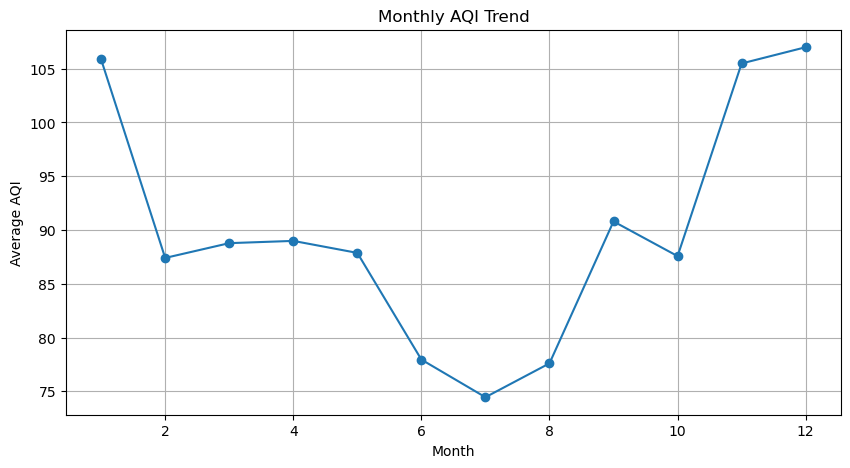

In [10]:
plt.figure(figsize=(10,5))
monthly_aqi.plot(marker='o')
plt.title('Monthly AQI Trend')
plt.xlabel('Month')
plt.ylabel('Average AQI')
plt.grid()
plt.show()

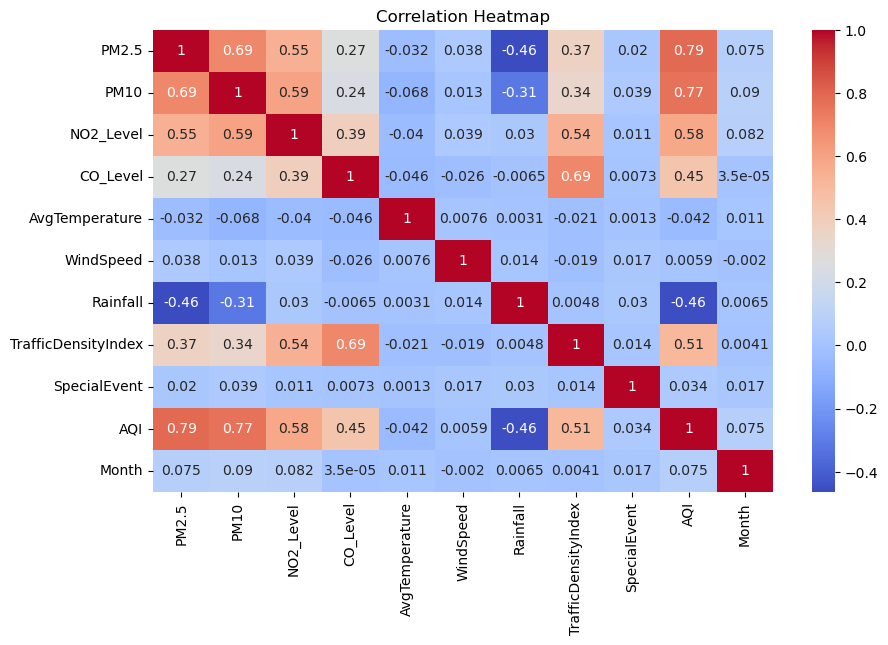

In [11]:
plt.figure(figsize=(10,6))
sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm'
)
plt.title('Correlation Heatmap')
plt.show()

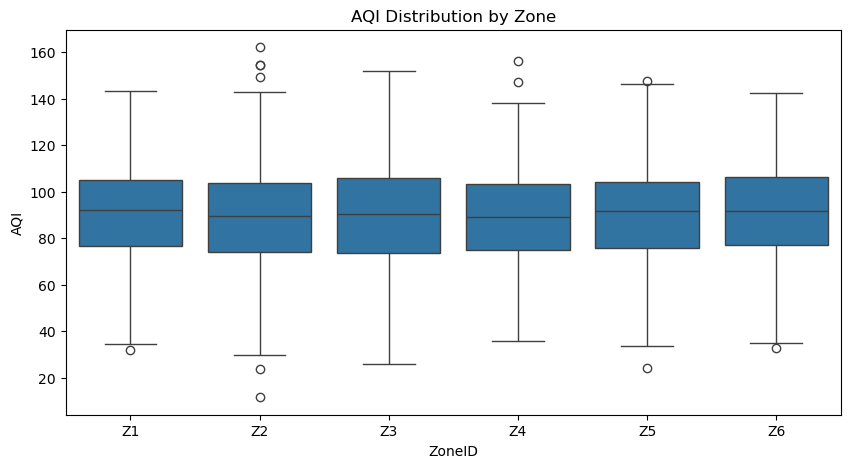

In [12]:
plt.figure(figsize=(10,5))
sns.boxplot(
    x='ZoneID',
    y='AQI',
    data=df
)
plt.title('AQI Distribution by Zone')
plt.show()

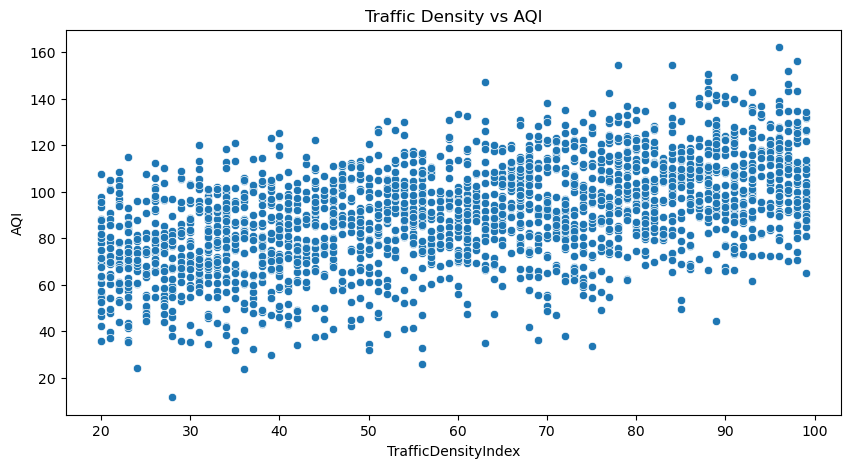

In [13]:
plt.figure(figsize=(10,5))
sns.scatterplot(
    x='TrafficDensityIndex',
    y='AQI',
    data=df
)
plt.title('Traffic Density vs AQI')
plt.show()

In [17]:
X = df[
    [
        'PM2.5',
        'PM10',
        'NO2_Level',
        'CO_Level',
        'AvgTemperature',
        'WindSpeed',
        'Rainfall',
        'TrafficDensityIndex',
        'SpecialEvent'
    ]
]
y = df['AQI']
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)
lr = LinearRegression()
lr.fit(X_train, y_train)
lr_pred = lr.predict(X_test)
rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)
gb = GradientBoostingRegressor(
    random_state=42
)
gb.fit(X_train, y_train)
gb_pred = gb.predict(X_test)
def evaluate(name, y_true, pred):
    mae = mean_absolute_error(y_true, pred)
    rmse = np.sqrt(
        mean_squared_error(y_true, pred)
    )
    r2 = r2_score(y_true, pred)
    print("\n", name)
    print("MAE :", round(mae,2))
    print("RMSE:", round(rmse,2))
    print("R2  :", round(r2,2))
evaluate("Linear Regression", y_test, lr_pred)
evaluate("Random Forest", y_test, rf_pred)
evaluate("Gradient Boosting", y_test, gb_pred)


 Linear Regression
MAE : 8.04
RMSE: 10.01
R2  : 0.8

 Random Forest
MAE : 8.55
RMSE: 10.53
R2  : 0.78

 Gradient Boosting
MAE : 8.29
RMSE: 10.33
R2  : 0.79


In [22]:
def classify_aqi(aqi):
    if aqi <= 50:
        return "Good"
    elif aqi <= 100:
        return "Moderate"
    elif aqi <= 200:
        return "Unhealthy"
    else:
        return "Severe"
print("----- AQI Prediction System -----")

try:
    zone = input("Enter Zone ID: ").upper()

    if zone not in zones:
        raise ValueError("Invalid Zone ID")
    temp = float(input("Temperature: "))
    wind = float(input("Wind Speed: "))
    rain = float(input("Rainfall: "))
    traffic = float(input("Traffic Index: "))
    event = int(input("Special Event (0/1): "))
    pm25 = max(10, 60 + traffic*0.3 - rain)
    pm10 = max(20, 100 + traffic*0.4 - rain)
    no2 = max(5, 30 + traffic*0.2)
    co = max(0.2, 1 + traffic*0.02)
    user_data = pd.DataFrame(
        [[
            pm25,
            pm10,
            no2,
            co,
            temp,
            wind,
            rain,
            traffic,
            event
        ]],
        columns=X.columns
    )
    prediction = rf.predict(user_data)[0]
    category = classify_aqi(prediction)
    print("\nPredicted AQI:",
          round(prediction,2))
    print("Category:",
          category)
    if category == "Severe":
        print("⚠ Warning: Dangerous Air Quality!")
except ValueError as e:
    print("Error:", e)

----- AQI Prediction System -----


Enter Zone ID:  z2
Temperature:  35
Wind Speed:  12
Rainfall:  4
Traffic Index:  2
Special Event (0/1):  1



Predicted AQI: 63.29
Category: Moderate
